In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import learning_curve

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    log_loss
)

### Information


In [2]:
df = pd.read_csv("C:\\project_anjini\\AcousticLocationDetection\\output\\features.csv")

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_98,Feature_99,Feature_100,Feature_101,Feature_102,Feature_103,Feature_104,Location,Recording,Filename
0,-159.97462,21.684065,-6.636372,-177.39162,-141.63808,47.700294,9.256035,-0.847084,35.888130,58.300070,...,0.292700,-4.092629,4.693751,0.163184,1923.896204,0.044943,0.109450,location_A,part1,clip_001.wav
1,-166.90172,14.794152,0.284155,-186.21277,-148.06601,46.463318,7.237769,-0.595750,38.127472,55.190056,...,0.052655,-3.942407,4.312454,0.166838,1939.016687,0.041711,0.161822,location_A,part1,clip_002.wav
2,-178.99722,10.584959,0.168215,-192.25656,-164.29008,55.025272,7.017437,-0.618277,45.760445,63.192440,...,-0.085992,-4.013736,4.013040,0.142006,1736.220979,0.030214,0.177167,location_A,part1,clip_003.wav
3,-194.53290,22.173200,3.044767,-213.79907,-179.04940,50.549503,12.578026,-2.252536,38.965570,61.208717,...,0.079956,-4.150668,4.005002,0.156091,1846.660050,0.039556,0.047090,location_A,part1,clip_004.wav
4,-181.55676,9.417584,0.767499,-192.64487,-170.03180,53.215584,6.929015,-0.718528,44.754760,61.020264,...,0.100419,-4.163673,3.713104,0.139283,1777.824402,0.030734,0.143913,location_A,part1,clip_005.wav


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 564
Columns: 107


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Columns: 107 entries, Feature_1 to Filename
dtypes: float64(104), str(3)
memory usage: 471.6 KB


In [5]:
df.isnull().sum()

Feature_1      0
Feature_2      0
Feature_3      0
Feature_4      0
Feature_5      0
              ..
Feature_103    0
Feature_104    0
Location       0
Recording      0
Filename       0
Length: 107, dtype: int64

In [6]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [7]:
df["Location"].value_counts()

Location
location_A    213
location_C    101
location_D     65
location_E     54
location_G     50
location_B     41
location_F     40
Name: count, dtype: int64

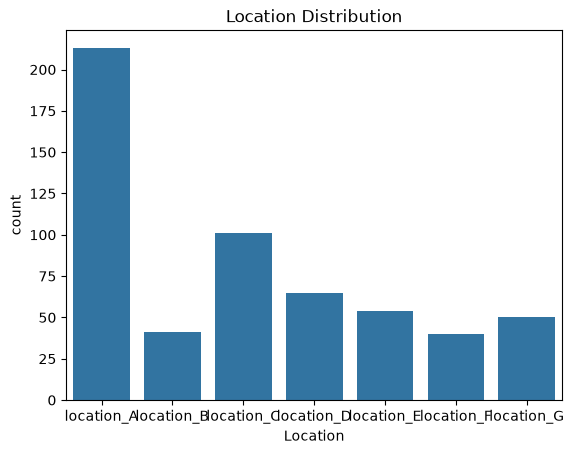

In [8]:
sns.countplot(data=df, x="Location")
plt.title("Location Distribution")
plt.show()

In [9]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_95,Feature_96,Feature_97,Feature_98,Feature_99,Feature_100,Feature_101,Feature_102,Feature_103,Feature_104
count,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,...,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000,564.000000
mean,-181.317676,17.479381,0.218252,-202.420971,-159.293545,23.353635,9.613232,-0.518921,10.976432,34.801194,...,3.138328,0.092692,3.253894,0.005968,-4.020492,4.217439,0.292992,2778.657495,0.130341,0.089884
std,32.808805,7.973701,1.433628,39.364883,29.833997,24.369991,3.237701,0.481706,26.482392,22.939042,...,1.368551,1.088890,0.399182,0.183659,1.283556,1.121044,0.136801,865.188156,0.086565,0.045078
min,-326.295650,4.648281,-8.487347,-505.964420,-305.126530,-34.327385,4.475228,-2.605254,-55.931030,-22.564255,...,-3.348678,-3.489681,2.514049,-0.860886,-9.308354,0.317592,0.096711,1188.224126,0.003077,0.011666
25%,-198.521410,12.114477,-0.037929,-222.129375,-176.071145,3.199946,7.354401,-0.798013,-14.268702,15.842083,...,2.474539,-0.555105,2.956890,-0.089798,-4.752806,3.474575,0.163204,1962.493576,0.045512,0.052577
50%,-179.923730,16.311733,0.334903,-202.427450,-157.880735,25.354765,8.684121,-0.443651,15.358801,35.696407,...,3.203712,0.179629,3.245588,-0.002443,-3.941149,4.280920,0.264066,2647.040525,0.124716,0.086797
75%,-160.866373,21.715986,0.800547,-180.032085,-139.951675,46.462088,11.565219,-0.201087,35.131981,57.554238,...,3.879631,0.809603,3.476768,0.092901,-3.147010,4.943417,0.414198,3620.892902,0.209040,0.122900
max,-99.242240,102.986730,4.112972,-106.257680,-77.029960,79.234310,21.774378,0.935768,68.661156,88.699800,...,7.356291,3.656115,5.463029,0.908219,0.295698,7.737493,0.615688,4703.921608,0.309784,0.208875


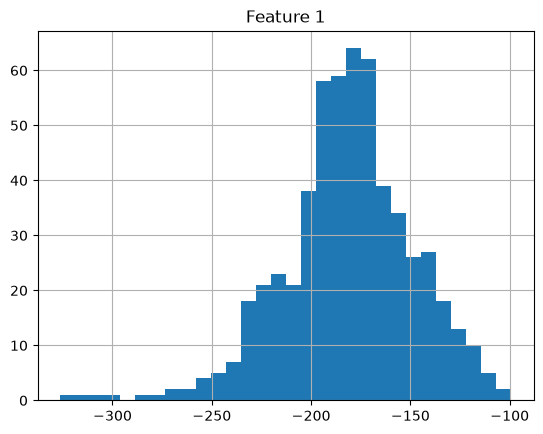

In [10]:
df["Feature_1"].hist(bins=30)
plt.title("Feature 1")
plt.show()

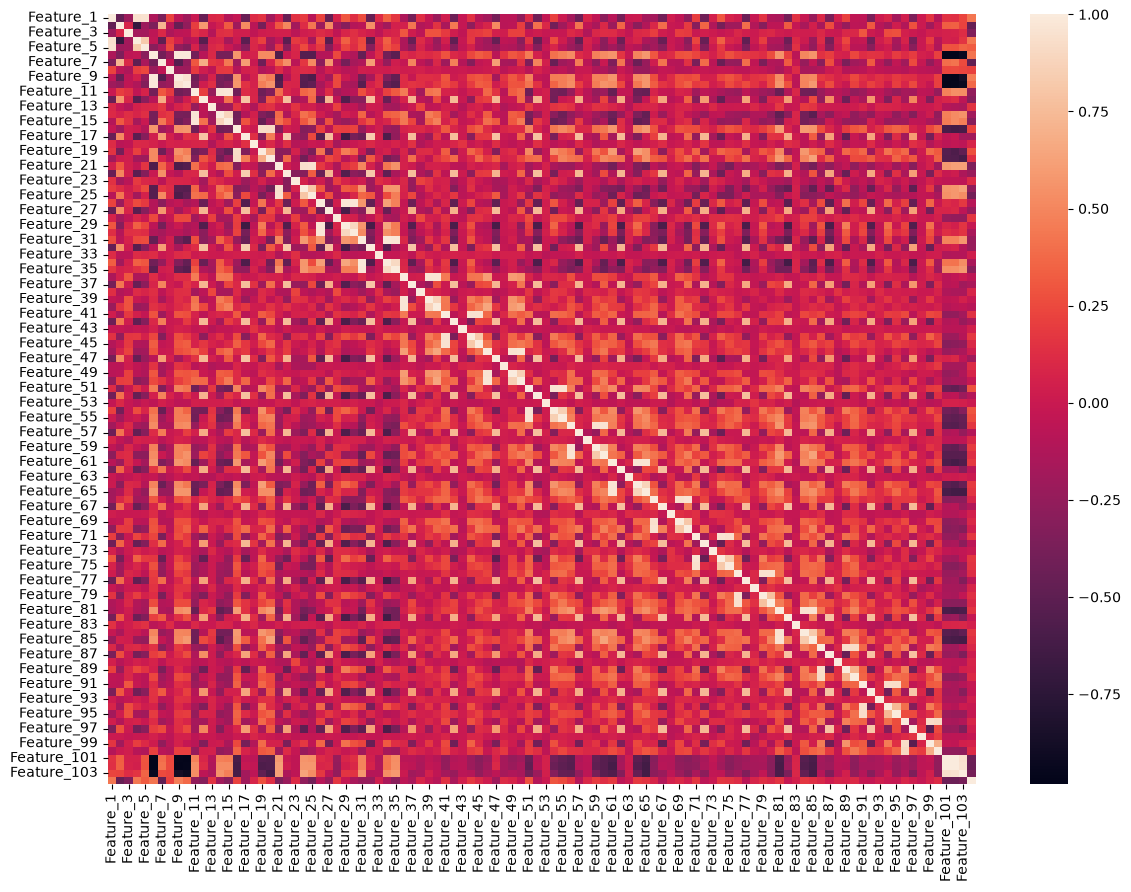

In [11]:
plt.figure(figsize=(14,10))
sns.heatmap(df.iloc[:, :104].corr())
plt.show()

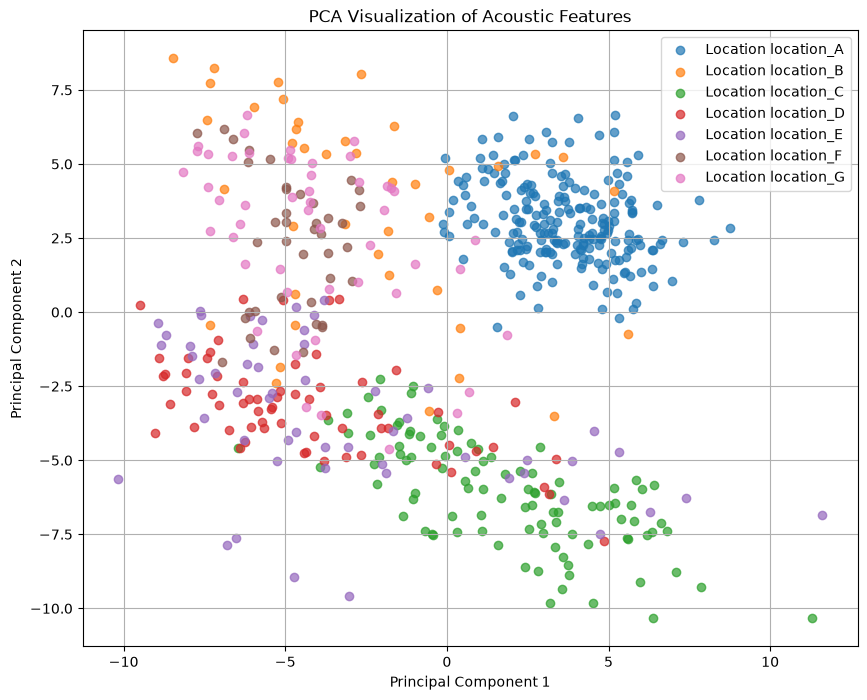

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Features
X = df.iloc[:, :104]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 8))

for location in sorted(df["Location"].unique()):
    mask = df["Location"] == location

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Location {location}",
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Acoustic Features")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
print(X.columns)

Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5',
       'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10',
       ...
       'Feature_95', 'Feature_96', 'Feature_97', 'Feature_98', 'Feature_99',
       'Feature_100', 'Feature_101', 'Feature_102', 'Feature_103',
       'Feature_104'],
      dtype='str', length=104)


In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["Location"] = encoder.fit_transform(df["Location"])

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_98,Feature_99,Feature_100,Feature_101,Feature_102,Feature_103,Feature_104,Location,Recording,Filename
0,-159.97462,21.684065,-6.636372,-177.39162,-141.63808,47.700294,9.256035,-0.847084,35.888130,58.300070,...,0.292700,-4.092629,4.693751,0.163184,1923.896204,0.044943,0.109450,0,part1,clip_001.wav
1,-166.90172,14.794152,0.284155,-186.21277,-148.06601,46.463318,7.237769,-0.595750,38.127472,55.190056,...,0.052655,-3.942407,4.312454,0.166838,1939.016687,0.041711,0.161822,0,part1,clip_002.wav
2,-178.99722,10.584959,0.168215,-192.25656,-164.29008,55.025272,7.017437,-0.618277,45.760445,63.192440,...,-0.085992,-4.013736,4.013040,0.142006,1736.220979,0.030214,0.177167,0,part1,clip_003.wav
3,-194.53290,22.173200,3.044767,-213.79907,-179.04940,50.549503,12.578026,-2.252536,38.965570,61.208717,...,0.079956,-4.150668,4.005002,0.156091,1846.660050,0.039556,0.047090,0,part1,clip_004.wav
4,-181.55676,9.417584,0.767499,-192.64487,-170.03180,53.215584,6.929015,-0.718528,44.754760,61.020264,...,0.100419,-4.163673,3.713104,0.139283,1777.824402,0.030734,0.143913,0,part1,clip_005.wav


In [15]:
print(df["Location"])

0      0
1      0
2      0
3      0
4      0
      ..
559    6
560    6
561    6
562    6
563    6
Name: Location, Length: 564, dtype: int64


In [16]:
X = df.iloc[:, :104]
y = df["Location"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model training

### LightGBM model


In [19]:
from lightgbm import LGBMClassifier
import time

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

start= time.time()

lgbm.fit(X_train, y_train)

end = time.time()

print("Training Time:", end-start)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002138 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15693
[LightGBM] [Info] Number of data points in the train set: 451, number of used features: 104
[LightGBM] [Info] Start training from score -0.975669
[LightGBM] [Info] Start training from score -2.614960
[LightGBM] [Info] Start training from score -1.717018
[LightGBM] [Info] Start training from score -2.160224
[LightGBM] [Info] Start training from score -2.350267
[LightGBM] [Info] Start training from score -2.645731
[LightGBM] [Info] Start training from score -2.422588
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [20]:
import time

start = time.time()

y_pred = lgbm.predict(X_test)

end = time.time()

print("Prediction Time:", end-start)

Prediction Time: 0.01038360595703125


In [21]:
lgbm_acc = accuracy_score(y_test, y_pred)

print("Accuracy:", lgbm_acc)

print(classification_report(y_test, y_pred))

Accuracy: 0.9557522123893806
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      0.62      0.77         8
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        11
           5       1.00      0.75      0.86         8
           6       0.67      1.00      0.80        10

    accuracy                           0.96       113
   macro avg       0.95      0.91      0.92       113
weighted avg       0.97      0.96      0.96       113



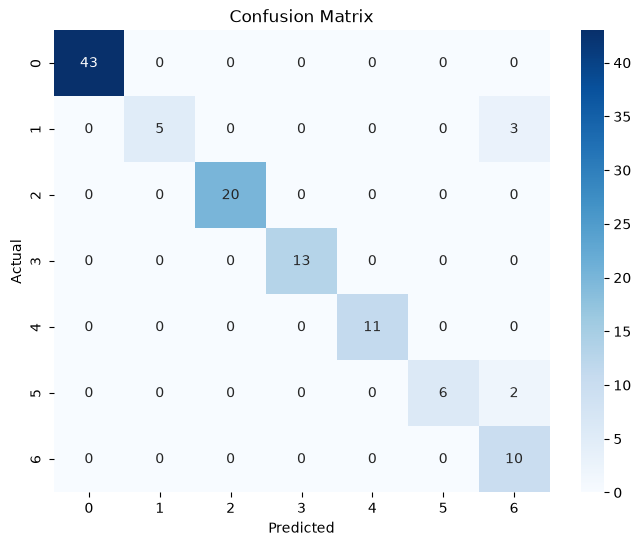

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=lgbm.classes_,
    yticklabels=lgbm.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [23]:
lgbm_train_acc = lgbm.score(X_train, y_train)
lgbm_test_acc = lgbm.score(X_test, y_test)

print("Training Accuracy :", lgbm_train_acc)
print("Testing Accuracy :", lgbm_test_acc)

Training Accuracy : 1.0
Testing Accuracy : 0.9557522123893806


In [24]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

lgbm = LGBMClassifier(random_state=42)

params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 10, -1],
    "num_leaves": [31, 50, 70]
}

grid_lgb = GridSearchCV(
    estimator=lgbm,
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_lgb.fit(X_train, y_train)

print(grid_lgb.best_params_)
print(grid_lgb.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002017 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15693
[LightGBM] [Info] Number of data points in the train set: 451, number of used features: 104
[LightGBM] [Info] Start training from score -0.975669
[LightGBM] [Info] Start training from score -2.614960
[LightGBM] [Info] Start training from score -1.717018
[LightGBM] [Info] Start training from score -2.160224
[LightGBM] [Info] Start training from score -2.350267
[LightGBM] [Info] Start training from score -2.645731
[LightGBM] [Info] Start training from score -2.422588
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [25]:
best_lgb = grid_lgb.best_estimator_

pred = best_lgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9557522123893806


In [26]:
print(lgbm.get_params())
print(best_lgb.get_params())

{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0}
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 200, 'n_jobs': None, 'num_leaves': 31, 'objective': None, 'random_state': 42, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0}


In [27]:
print("Best Parameters:")
print(grid_lgb.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_lgb.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}

Best Cross Validation Accuracy:
0.9645177045177047


In [28]:
scores = cross_val_score(
    best_lgb,
    X,
    y,
    cv=5
)

print(scores)
print("Mean Accuracy:", scores.mean())

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15696
[LightGBM] [Info] Number of data points in the train set: 451, number of used features: 104
[LightGBM] [Info] Start training from score -0.975669
[LightGBM] [Info] Start training from score -2.614960
[LightGBM] [Info] Start training from score -1.717018
[LightGBM] [Info] Start training from score -2.160224
[LightGBM] [Info] Start training from score -2.350267
[LightGBM] [Info] Start training from score -2.645731
[LightGBM] [Info] Start training from score -2.422588
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

In [29]:
y_test_bin = label_binarize(
    y_test,
    classes=best_lgb.classes_
)

y_prob = best_lgb.predict_proba(X_test)

lgbm_roc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr'
)

print("ROC-AUC:", lgbm_roc)

ROC-AUC: 0.9978072782511063


In [30]:
lgbm_kappa = cohen_kappa_score(
    y_test,
    pred
)

print("Kappa Score:",lgbm_kappa)

lgbm_mcc = matthews_corrcoef(
    y_test,
    pred
)

print("MCC:",lgbm_mcc)

Kappa Score: 0.9434547638110489
MCC: 0.9452561772502468


In [31]:
lgbm_loss = log_loss(
    y_test,
    y_prob
)

print(lgbm_loss)

0.17904422541350842


         Feature  Importance
39    Feature_40         635
14    Feature_15         579
100  Feature_101         518
10    Feature_11         485
49    Feature_50         441
13    Feature_14         434
9     Feature_10         393
84    Feature_85         389
101  Feature_102         377
5      Feature_6         363
102  Feature_103         355
11    Feature_12         353
8      Feature_9         332
90    Feature_91         306
82    Feature_83         290
6      Feature_7         273
24    Feature_25         268
59    Feature_60         253
38    Feature_39         253
29    Feature_30         250


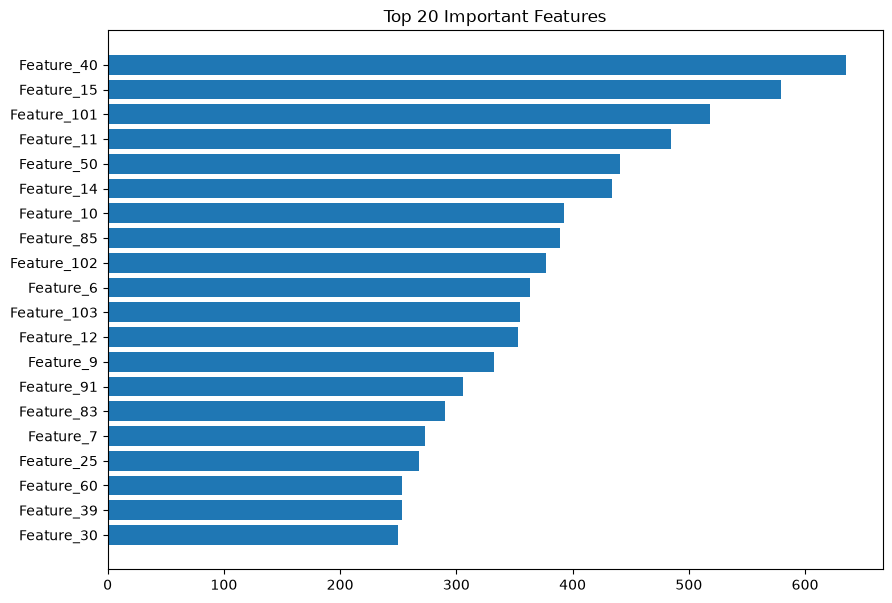

In [32]:
importance = best_lgb.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))

plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"][:20],
    importance_df["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

[LightGBM] [Warning] Contains only one class
[LightGBM] [Info] Number of positive: 0, number of negative: 45
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1687
[LightGBM] [Info] Number of data points in the train set: 45, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.000000 -> initscore=-34.538776
[LightGBM] [Info] Start training from score -34.538776
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there 

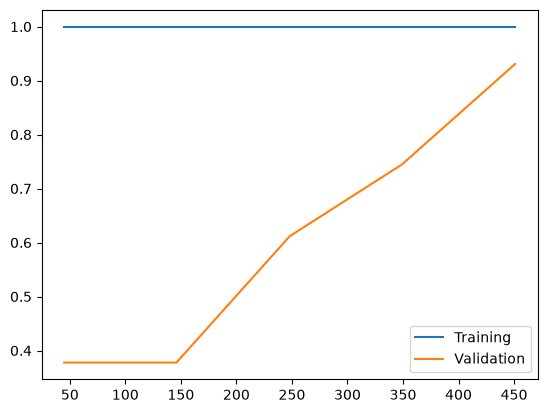

In [33]:
train_sizes, train_scores, test_scores = learning_curve(
    best_lgb,
    X,
    y,
    cv=5
)

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    label="Training"
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    label="Validation"
)

plt.legend()

plt.show()

In [34]:
import joblib
import os

joblib.dump(best_lgb,"lightgbm.pkl")

print(
    os.path.getsize("lightgbm.pkl")/1024,
    "KB"
)

2415.96484375 KB


### Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier
import time

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

start = time.time()

rf.fit(X_train,y_train)

end = time.time()

print("Training Time:", end-start)


Training Time: 0.5069215297698975


In [36]:
import time

start = time.time()

y_pred = rf.predict(X_test)

end = time.time()

print("Prediction Time:", end-start)

Prediction Time: 0.04889559745788574


In [37]:
rf_acc = accuracy_score(y_test,y_pred)

print("Accuracy:", rf_acc)

print(classification_report(y_test, y_pred))

Accuracy: 0.9734513274336283
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      0.75      0.86         8
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        11
           5       0.88      0.88      0.88         8
           6       0.83      1.00      0.91        10

    accuracy                           0.97       113
   macro avg       0.96      0.95      0.95       113
weighted avg       0.98      0.97      0.97       113



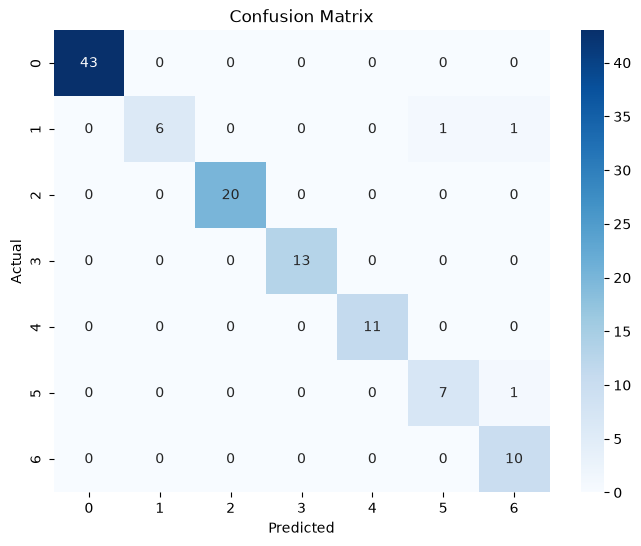

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [39]:
rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)

print("Training Accuracy :", rf_train_acc)
print("Testing Accuracy :", rf_test_acc)

Training Accuracy : 1.0
Testing Accuracy : 0.9734513274336283


In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

print("\nBest CV Accuracy:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV Accuracy:
0.9733821733821735


In [41]:
best_rf = grid_rf.best_estimator_

pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, pred))

Test Accuracy: 0.9734513274336283


In [42]:
scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.94690265 0.96460177 0.92920354 0.95575221 0.90178571]
Mean Accuracy: 0.939649178255373


In [43]:
y_test_bin = label_binarize(
    y_test,
    classes=best_rf.classes_
)

y_prob = best_rf.predict_proba(X_test)

rf_roc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr'
)

print("ROC-AUC:", rf_roc)

ROC-AUC: 0.9982770292583052


In [44]:
rf_kappa = cohen_kappa_score(
    y_test,
    pred
)

print("Kappa Score:",rf_kappa)

rf_mcc = matthews_corrcoef(
    y_test,
    pred
)

print("MCC:",rf_mcc)

Kappa Score: 0.9660932186437288
MCC: 0.9664801975779351


In [45]:
rf_loss = log_loss(
    y_test,
    y_prob
)

print(rf_loss)

0.28052703001681145


         Feature  Importance
100  Feature_101    0.072470
9     Feature_10    0.061916
5      Feature_6    0.051889
8      Feature_9    0.047300
101  Feature_102    0.045762
10    Feature_11    0.033420
14    Feature_15    0.030922
6      Feature_7    0.028160
102  Feature_103    0.027795
55    Feature_56    0.024215
13    Feature_14    0.022974
59    Feature_60    0.022799
1      Feature_2    0.021138
31    Feature_32    0.019779
34    Feature_35    0.017972
30    Feature_31    0.015561
64    Feature_65    0.014826
28    Feature_29    0.014415
49    Feature_50    0.014297
45    Feature_46    0.014162


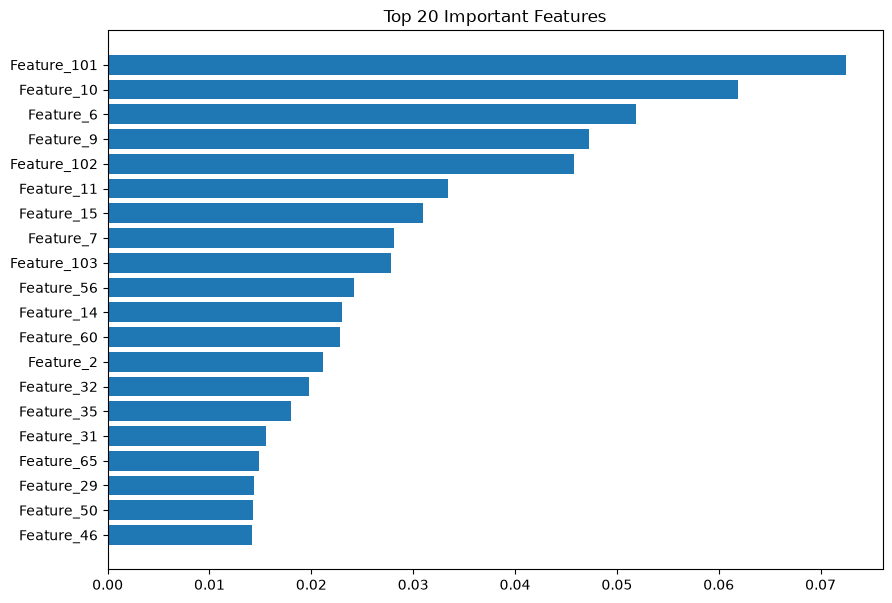

In [46]:
importance = best_rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))
plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"][:20],
    importance_df["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

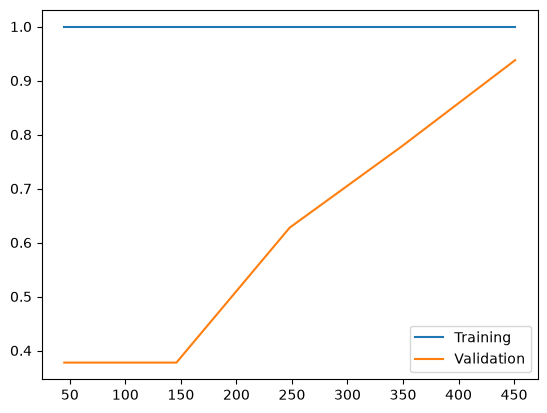

In [47]:
train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X,
    y,
    cv=5
)

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    label="Training"
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    label="Validation"
)

plt.legend()

plt.show()

In [48]:
import joblib
import os

joblib.dump(best_rf,"randomforest.pkl")

print(
    os.path.getsize("randomforest.pkl")/1024,
    "KB"
)

884.5634765625 KB


### SVM Model

In [49]:
from sklearn.svm import SVC
import time

svm = SVC()

start = time.time()

svm.fit(X_train_scaled, y_train)

end = time.time()

print("Training Time:", end-start, "seconds")



Training Time: 0.05853438377380371 seconds


In [50]:
start = time.time()

y_pred = svm.predict(X_test_scaled)

end = time.time()

print("Prediction Time:", end-start, "seconds")

Prediction Time: 0.008273124694824219 seconds


In [51]:
svm_acc = accuracy_score(y_test, y_pred)
print("Accuracy:", svm_acc)

print(classification_report(y_test, y_pred))

Accuracy: 0.9380530973451328
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        43
           1       1.00      0.62      0.77         8
           2       0.95      1.00      0.98        20
           3       1.00      0.85      0.92        13
           4       0.85      1.00      0.92        11
           5       1.00      0.88      0.93         8
           6       0.71      1.00      0.83        10

    accuracy                           0.94       113
   macro avg       0.93      0.90      0.90       113
weighted avg       0.95      0.94      0.94       113



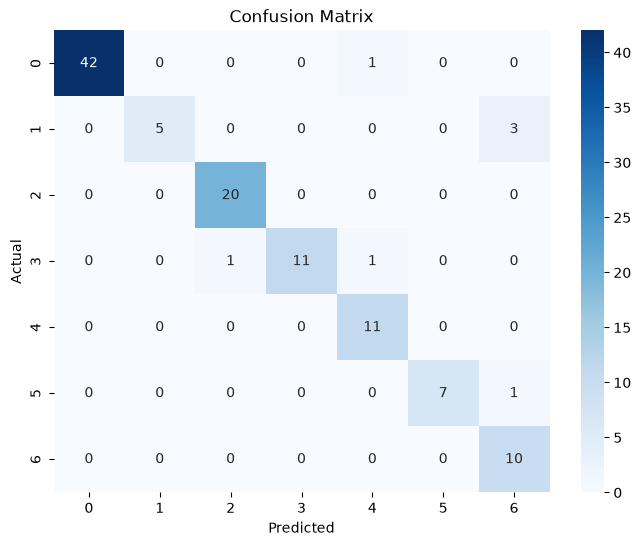

In [52]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=svm.classes_,
    yticklabels=svm.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [53]:
svm_train_acc = svm.score(X_train_scaled, y_train)
svm_test_acc = svm.score(X_test_scaled, y_test)

print("Training Accuracy :", svm_train_acc)
print("Testing Accuracy :", svm_test_acc)

Training Accuracy : 1.0
Testing Accuracy : 0.9380530973451328


In [54]:
scores = cross_val_score(
    svm,
    X,
    y,
    cv=5
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.62831858 0.61061947 0.66371681 0.65486726 0.64285714]
Mean Accuracy: 0.6400758533501897


In [55]:
svm_kappa = cohen_kappa_score(
    y_test,
    y_pred
)

print("Kappa Score:",svm_kappa)

svm_mcc = matthews_corrcoef(
    y_test,
    y_pred
)

print("MCC:",svm_mcc)

Kappa Score: 0.92106576190001
MCC: 0.9227231876559355


In [56]:
svm_loss = log_loss(
    y_test,
    y_prob
)

print(svm_loss)

0.28052703001681145


In [57]:
import joblib
import os

joblib.dump(svm,"svm.pkl")

print(
    os.path.getsize("svm.pkl")/1024,
    "KB"
)

253.4482421875 KB


### Extra trees

In [58]:
from sklearn.ensemble import ExtraTreesClassifier
import time

extra = ExtraTreesClassifier(
    n_estimators=300,
    random_state=42
)

start = time.time()

extra.fit(X_train,y_train)

end = time.time()

print("Training Time:", end-start)

Training Time: 0.5607671737670898


In [59]:
import time

start = time.time()

y_pred = extra.predict(X_test)

end = time.time()

print("Prediction Time:", end-start)

Prediction Time: 0.03221464157104492


In [60]:
extra_acc = accuracy_score(y_test, y_pred)

print("Accuracy:", extra_acc)

print(classification_report(y_test, y_pred))

Accuracy: 0.9646017699115044
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      0.75      0.86         8
           2       0.95      1.00      0.98        20
           3       1.00      0.92      0.96        13
           4       1.00      1.00      1.00        11
           5       1.00      0.88      0.93         8
           6       0.77      1.00      0.87        10

    accuracy                           0.96       113
   macro avg       0.96      0.94      0.94       113
weighted avg       0.97      0.96      0.96       113



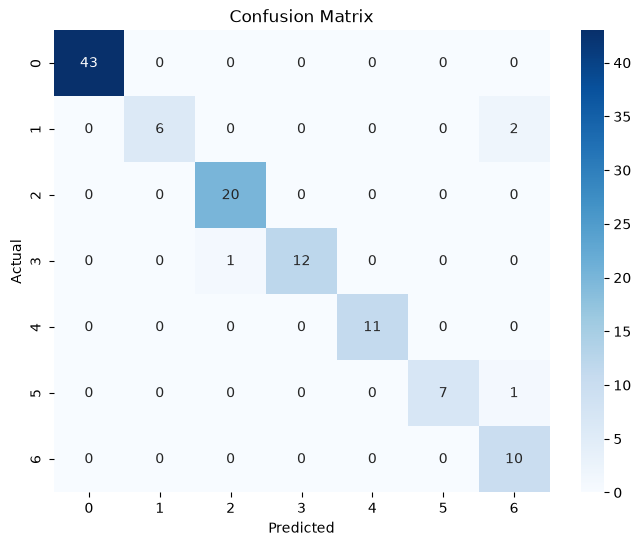

In [61]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=extra.classes_,
    yticklabels=extra.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [62]:
extra_train_acc = extra.score(X_train, y_train)
extra_test_acc = extra.score(X_test, y_test)

print("Training Accuracy :", extra_train_acc)
print("Testing Accuracy :", extra_test_acc)

Training Accuracy : 1.0
Testing Accuracy : 0.9646017699115044


In [63]:
scores = cross_val_score(
    extra,
    X,
    y,
    cv=5
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.94690265 0.96460177 0.94690265 0.97345133 0.91964286]
Mean Accuracy: 0.9503002528445006


In [64]:
y_test_bin = label_binarize(
    y_test,
    classes=extra.classes_
)

y_prob = extra.predict_proba(X_test)

extra_roc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr'
)

print("ROC-AUC:", extra_roc)

ROC-AUC: 0.9985544217687075


In [65]:
extra_kappa = cohen_kappa_score(
    y_test,
    y_pred
)

print("Kappa Score:",extra_kappa)

extra_mcc = matthews_corrcoef(
    y_test,
    y_pred
)

print("MCC:",extra_mcc)

Kappa Score: 0.9547502252477725
MCC: 0.9555175943586746


In [66]:
extra_loss = log_loss(
    y_test,
    y_prob
)

print(extra_loss)

0.2778535091831255


         Feature  Importance
5      Feature_6    0.052617
100  Feature_101    0.045935
102  Feature_103    0.036179
101  Feature_102    0.035929
9     Feature_10    0.034903
8      Feature_9    0.033634
33    Feature_34    0.023941
30    Feature_31    0.023710
14    Feature_15    0.021209
13    Feature_14    0.021189
10    Feature_11    0.020685
34    Feature_35    0.020082
60    Feature_61    0.018271
64    Feature_65    0.016966
84    Feature_85    0.016194
24    Feature_25    0.014977
80    Feature_81    0.014055
59    Feature_60    0.013741
1      Feature_2    0.013502
45    Feature_46    0.013162


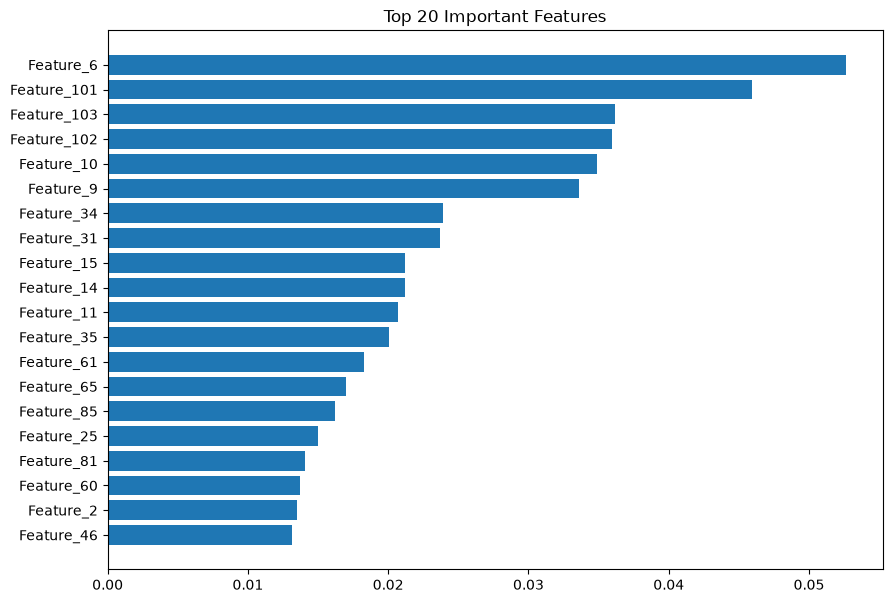

In [67]:
importance = extra.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))
plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"][:20],
    importance_df["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

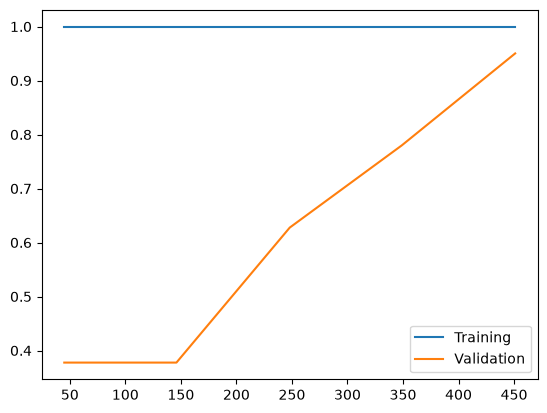

In [68]:
train_sizes, train_scores, test_scores = learning_curve(
    extra,
    X,
    y,
    cv=5
)

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    label="Training"
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    label="Validation"
)

plt.legend()

plt.show()

In [69]:
import joblib
import os

joblib.dump(extra,"extratrees.pkl")

print(
    os.path.getsize("extratrees.pkl")/1024,
    "KB"
)

6408.2197265625 KB


### XGBoost model

In [70]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",   
    num_class=6,                 
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="mlogloss",
    random_state=42
)

start = time.time()

xgb.fit(X_train,y_train)

end = time.time()

print("Training Time:", end-start)


Training Time: 2.2173662185668945


In [71]:
import time

start = time.time()

y_pred = xgb.predict(X_test)

end = time.time()

print("Prediction Time:", end-start)

Prediction Time: 0.04867124557495117


In [72]:
xgb_acc = accuracy_score(y_test, y_pred)
print("Accuracy:", xgb_acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.9469026548672567
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      0.75      0.86         8
           2       0.95      1.00      0.98        20
           3       1.00      0.92      0.96        13
           4       1.00      1.00      1.00        11
           5       0.86      0.75      0.80         8
           6       0.69      0.90      0.78        10

    accuracy                           0.95       113
   macro avg       0.93      0.90      0.91       113
weighted avg       0.95      0.95      0.95       113



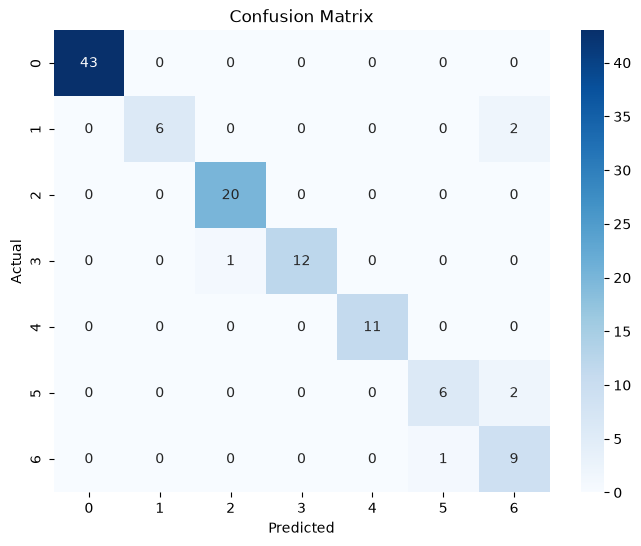

In [73]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=xgb.classes_,
    yticklabels=xgb.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [74]:
xgb_train_acc = xgb.score(X_train, y_train)
xgb_test_acc = xgb.score(X_test, y_test)

print("Training Accuracy :", xgb_train_acc)
print("Testing Accuracy :", xgb_test_acc)

Training Accuracy : 1.0
Testing Accuracy : 0.9469026548672567


In [75]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_xgb.fit(X_train, y_train)

print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
0.9645177045177045


In [76]:
best_xgb = grid_xgb.best_estimator_

pred = best_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9557522123893806


In [77]:
scores = cross_val_score(
    best_xgb,
    X,
    y,
    cv=5
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.91150442 0.91150442 0.91150442 0.9380531  0.85714286]
Mean Accuracy: 0.9059418457648546


In [78]:
y_test_bin = label_binarize(
    y_test,
    classes=best_xgb.classes_
)

y_prob = best_xgb.predict_proba(X_test)

xgb_roc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr'
)

print("ROC-AUC:", xgb_roc)

ROC-AUC: 0.9983174823327389


In [79]:
xgb_kappa = cohen_kappa_score(
    y_test,
    pred
)

print("Kappa Score:",xgb_kappa)

xgb_mcc = matthews_corrcoef(
    y_test,
    pred
)

print("MCC:",xgb_mcc)

Kappa Score: 0.9434264543907079
MCC: 0.9446598282804419


In [80]:
xgb_loss = log_loss(
    y_test,
    y_prob
)

print(xgb_loss)

0.15015561878681183


         Feature  Importance
9     Feature_10    0.088722
13    Feature_14    0.082162
100  Feature_101    0.056924
8      Feature_9    0.047015
49    Feature_50    0.037592
50    Feature_51    0.035054
29    Feature_30    0.034742
10    Feature_11    0.031867
28    Feature_29    0.027366
95    Feature_96    0.026407
6      Feature_7    0.025289
24    Feature_25    0.022306
41    Feature_42    0.018804
19    Feature_20    0.017663
14    Feature_15    0.016967
34    Feature_35    0.016918
98    Feature_99    0.015922
60    Feature_61    0.014959
93    Feature_94    0.014847
53    Feature_54    0.014728


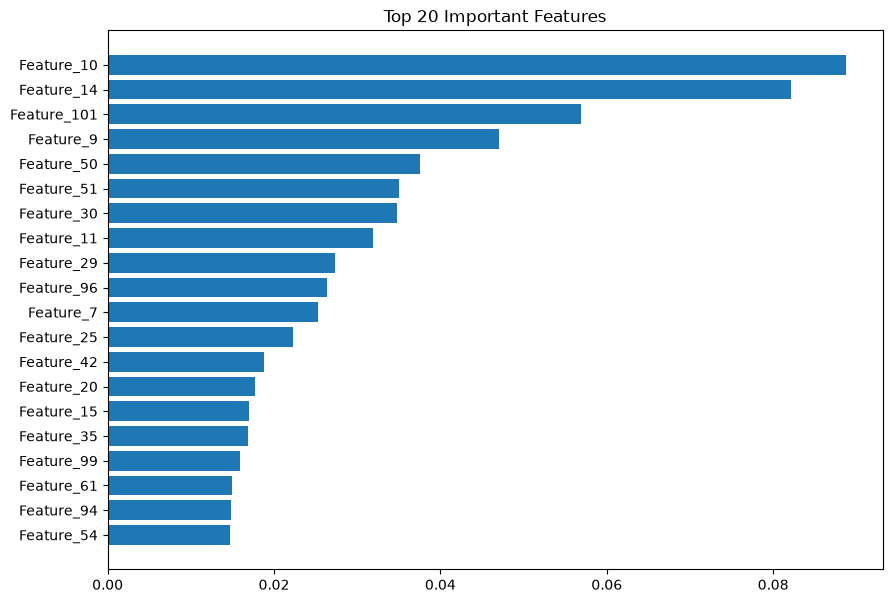

In [81]:
importance = best_xgb.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))
plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"][:20],
    importance_df["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

c:\project_anjini\AcousticLocationDetection\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\project_anjini\AcousticLocationDetection\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\project_anjini\AcousticLocationDetection\.venv\Lib\site-packages\xgboost\core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\project_anjini\AcousticLocationDetection\.venv\Lib\site-packages\xgboost\sklearn.p

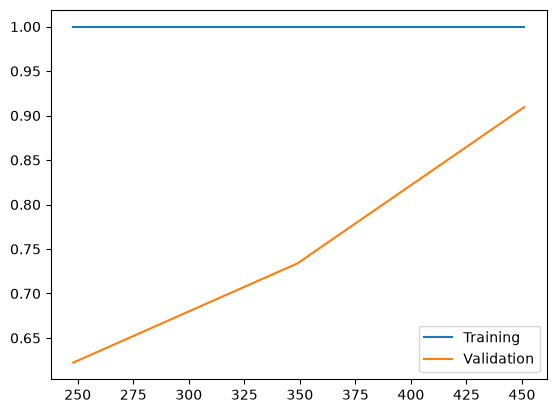

In [82]:
train_sizes, train_scores, test_scores = learning_curve(
    best_xgb,
    X,
    y,
    cv=5
)

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    label="Training"
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    label="Validation"
)

plt.legend()

plt.show()

In [83]:
import joblib
import os

joblib.dump(best_xgb,"xgboost.pkl")

print(
    os.path.getsize("xgboost.pkl")/1024,
    "KB"
)

1575.943359375 KB


### Catboost

In [84]:
from catboost import CatBoostClassifier
import time

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=False
)

start = time.time()

cat.fit(X_train,y_train)

end = time.time()

print("Training Time:", end-start)

Training Time: 13.112936735153198


In [85]:
import time

start = time.time()

y_pred = cat.predict(X_test)

end = time.time()

print("Prediction Time:", end-start)

Prediction Time: 0.028366804122924805


In [86]:
cat_acc = accuracy_score(y_test, y_pred)

print("Accuracy:", cat_acc)

print(classification_report(y_test, y_pred))

Accuracy: 0.9646017699115044
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        43
           1       1.00      0.62      0.77         8
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00        11
           5       1.00      0.88      0.93         8
           6       0.71      1.00      0.83        10

    accuracy                           0.96       113
   macro avg       0.96      0.93      0.93       113
weighted avg       0.97      0.96      0.96       113



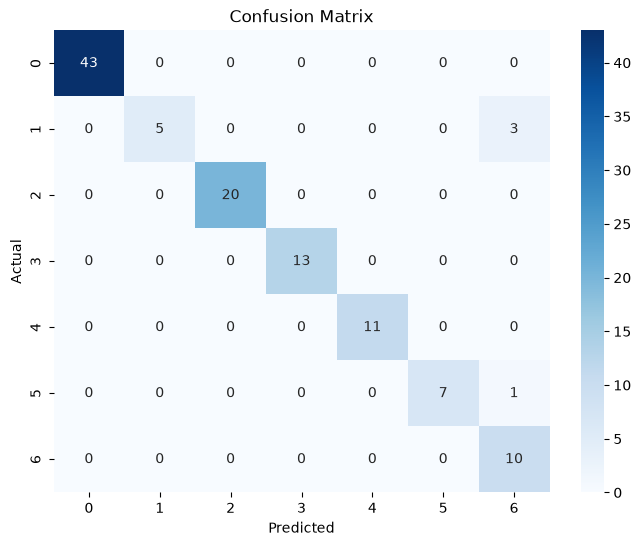

In [87]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cat.classes_,
    yticklabels=cat.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [88]:
cat_train_acc = cat.score(X_train, y_train)
cat_test_acc = cat.score(X_test, y_test)

print("Training Accuracy :", cat_train_acc)
print("Testing Accuracy :", cat_test_acc)

Training Accuracy : 1.0
Testing Accuracy : 0.9646017699115044


In [89]:
scores = cross_val_score(
    cat,
    X,
    y,
    cv=5
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.96460177 0.94690265 0.92035398 0.97345133 0.88392857]
Mean Accuracy: 0.9378476611883692


In [91]:
y_test_bin = label_binarize(
    y_test,
    classes=cat.classes_
)

y_prob = cat.predict_proba(X_test)

cat_roc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr'
)

print("ROC-AUC:", cat_roc)

ROC-AUC: 0.9985321312991217


In [92]:
cat_kappa = cohen_kappa_score(
    y_test,
    y_pred
)

print("Kappa Score:",cat_kappa)

cat_mcc = matthews_corrcoef(
    y_test,
    y_pred
)

print("MCC:",cat_mcc)

Kappa Score: 0.9547728637182309
MCC: 0.9560185472759225


In [93]:
cat_loss = log_loss(
    y_test,
    y_prob
)

print(cat_loss)

0.161429138455733


         Feature  Importance
5      Feature_6    7.271351
100  Feature_101    6.152060
8      Feature_9    5.783837
9     Feature_10    5.584987
10    Feature_11    4.347389
14    Feature_15    3.765332
101  Feature_102    3.169223
30    Feature_31    2.862666
13    Feature_14    2.858935
95    Feature_96    2.724847
6      Feature_7    2.699933
25    Feature_26    2.560365
102  Feature_103    2.203320
34    Feature_35    2.044051
64    Feature_65    1.906809
29    Feature_30    1.811333
28    Feature_29    1.702795
39    Feature_40    1.682948
24    Feature_25    1.677882
49    Feature_50    1.660659


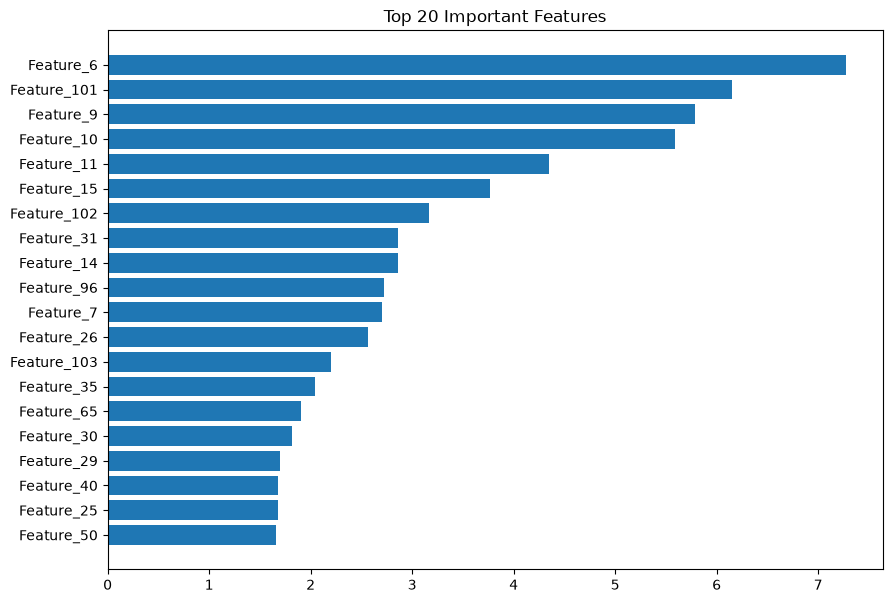

In [94]:
importance = cat.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(20))
plt.figure(figsize=(10,7))

plt.barh(
    importance_df["Feature"][:20],
    importance_df["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

c:\project_anjini\AcousticLocationDetection\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "c:\project_anjini\AcousticLocationDetection\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\project_anjini\AcousticLocationDetection\.venv\Lib\site-packages\catboost\core.py", line 5547, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,


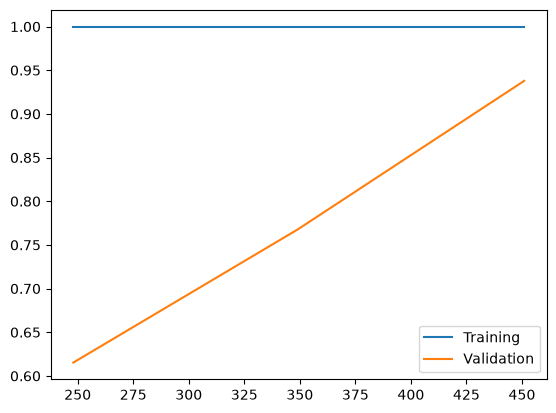

In [95]:
train_sizes, train_scores, test_scores = learning_curve(
    cat,
    X,
    y,
    cv=5
)

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    label="Training"
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    label="Validation"
)

plt.legend()

plt.show()

In [96]:
import joblib
import os

joblib.dump(cat,"catboost.pkl")

print(
    os.path.getsize("catboost.pkl")/1024,
    "KB"
)

1242.375 KB


## Result

In [97]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Extra Trees",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "SVM",
    ],
    "Accuracy": [
        rf_acc,
        extra_acc,
        xgb_acc,
        lgbm_acc,
        cat_acc,
        svm_acc,
    ],
    "Training accuracy":[
        rf_train_acc,
        extra_train_acc,
        xgb_train_acc,
        lgbm_train_acc,
        cat_train_acc,
        svm_train_acc,
    ],
    "Testing accuracy":[
        rf_test_acc,
        extra_test_acc,
        xgb_test_acc,
        lgbm_test_acc,
        cat_test_acc,
        svm_test_acc,
    ],
    "Kappa":[
        rf_kappa,
        extra_kappa,
        xgb_kappa,
        lgbm_kappa,
        cat_kappa,
        svm_kappa,
    ],
    "MCC":[
        rf_mcc,
        extra_mcc,
        xgb_mcc,
        lgbm_mcc,
        cat_mcc,
        svm_mcc,
    ],
    "ROC_AUC":[
        rf_roc,
        extra_roc,
        xgb_roc,
        lgbm_roc,
        cat_roc,
        0,
    ],
    "Log Loss":[
        rf_loss,
        extra_loss,
        xgb_loss,
        lgbm_loss,
        cat_loss,
        svm_loss,
    ]

})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Training accuracy,Testing accuracy,Kappa,MCC,ROC_AUC,Log Loss
0,Random Forest,0.973451,1.0,0.973451,0.966093,0.966480,0.998277,0.280527
1,Extra Trees,0.964602,1.0,0.964602,0.954750,0.955518,0.998554,0.277854
4,CatBoost,0.964602,1.0,0.964602,0.954773,0.956019,0.998532,0.161429
3,LightGBM,0.955752,1.0,0.955752,0.943455,0.945256,0.997807,0.179044
2,XGBoost,0.946903,1.0,0.946903,0.943426,0.944660,0.998317,0.150156
5,SVM,0.938053,1.0,0.938053,0.921066,0.922723,0.000000,0.280527
